In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv("/content/Copy of Class_Occupancy_Data.csv")

In [ ]:
df.head()

,Record_Date,Record_Time,Course_ID,Term_TermCode,Class_ClassSection,ClassEnrolment_EnrolmentCapacity,ClassEnrolment_EnrolmentTotal,Course_CatalogNumber,CourseCatalog_CourseTitleCode,CourseCatalog_CourseTitleName,...,Meeting_ClassEndDate,Class_Start_Time,Class_End_Time,Facility_ID,Facility_PersonCapacity,Day_of_Week,Max_Occupancy,Max_Occupancy_Perc,Traffic_In,Traffic_Out
0,2021-09-28,10:30:00,1624,1214,H01,60,37,1166,1624,MS Word and Presentations,...,2021-12-08,8:00:00,9:30:00,3-172,45,Tuesday,4,0.088889,0,7
1,2021-09-28,10:45:00,2995,1214,H01,60,53,1007,2995,Business Computer Applications,...,2021-12-08,8:00:00,9:30:00,3-157,55,Tuesday,4,0.072727,4,1
2,2021-09-28,10:45:00,3017,1214,H01,45,44,2019,3017,Strategic Management,...,2021-12-08,8:00:00,9:30:00,3-154,45,Tuesday,0,0.000000,0,0
3,2021-09-28,10:45:00,2992,1214,H04,60,58,1004,2992,Introduction to Accounting,...,2021-12-08,9:30:00,11:00:00,3-172,45,Tuesday,0,0.000000,0,0
4,2021-09-28,10:45:00,1624,1214,H01,60,37,1166,1624,MS Word and Presentations,...,2021-12-08,8:00:00,9:30:00,3-172,45,Tuesday,0,0.000000,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32125 entries, 0 to 32124
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Record_Date                       32125 non-null  object 
 1   Record_Time                       32125 non-null  object 
 2   Course_ID                         32125 non-null  int64  
 3   Term_TermCode                     32125 non-null  int64  
 4   Class_ClassSection                32125 non-null  object 
 5   ClassEnrolment_EnrolmentCapacity  32125 non-null  int64  
 6   ClassEnrolment_EnrolmentTotal     32125 non-null  int64  
 7   Course_CatalogNumber              32125 non-null  int64  
 8   CourseCatalog_CourseTitleCode     32125 non-null  int64  
 9   CourseCatalog_CourseTitleName     32125 non-null  object 
 10  Class_ClassNumber                 32125 non-null  int64  
 11  Class_ClassName                   32125 non-null  object 
 12  Clas

#Dropping Unnecassary columns

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=["Course_ID", "Term_TermCode", "Course_CatalogNumber", "CourseCatalog_CourseTitleCode", "Class_ClassNumber", "CourseCatalog_CourseTitleName", "Class_ClassStatus", "Class_StartDate", "Class_EndDate", "Meeting_ClassStartDate", "Meeting_ClassEndDate", "Class_ClassName"])

In [ ]:
df.head()

,Record_Date,Record_Time,Class_ClassSection,ClassEnrolment_EnrolmentCapacity,ClassEnrolment_EnrolmentTotal,Class_InstructionMode,CourseOffer_Subject,Class_Start_Time,Class_End_Time,Facility_ID,Facility_PersonCapacity,Day_of_Week,Max_Occupancy,Max_Occupancy_Perc,Traffic_In,Traffic_Out
0,2021-09-28,10:30:00,H01,60,37,Hyflex,BUSN,8:00:00,9:30:00,3-172,45,Tuesday,4,0.088889,0,7
1,2021-09-28,10:45:00,H01,60,53,Hyflex,BUSD,8:00:00,9:30:00,3-157,55,Tuesday,4,0.072727,4,1
2,2021-09-28,10:45:00,H01,45,44,Hyflex,BUSD,8:00:00,9:30:00,3-154,45,Tuesday,0,0.000000,0,0
3,2021-09-28,10:45:00,H04,60,58,Hyflex,BUSD,9:30:00,11:00:00,3-172,45,Tuesday,0,0.000000,0,0
4,2021-09-28,10:45:00,H01,60,37,Hyflex,BUSN,8:00:00,9:30:00,3-172,45,Tuesday,0,0.000000,0,0


In [ ]:
df.shape

(32125, 16)

In [ ]:
df.dtypes

Record_Date                          object
Record_Time                          object
Class_ClassSection                   object
ClassEnrolment_EnrolmentCapacity      int64
ClassEnrolment_EnrolmentTotal         int64
Class_InstructionMode                object
CourseOffer_Subject                  object
Class_Start_Time                     object
Class_End_Time                       object
Facility_ID                          object
Facility_PersonCapacity               int64
Day_of_Week                          object
Max_Occupancy                         int64
Max_Occupancy_Perc                  float64
Traffic_In                            int64
Traffic_Out                           int64
dtype: object

In [ ]:
df.isnull().sum()

Record_Date                         0
Record_Time                         0
Class_ClassSection                  0
ClassEnrolment_EnrolmentCapacity    0
ClassEnrolment_EnrolmentTotal       0
Class_InstructionMode               0
CourseOffer_Subject                 0
Class_Start_Time                    0
Class_End_Time                      0
Facility_ID                         0
Facility_PersonCapacity             0
Day_of_Week                         0
Max_Occupancy                       0
Max_Occupancy_Perc                  0
Traffic_In                          0
Traffic_Out                         0
dtype: int64

In [ ]:
df = df.dropna()

#Changing datatypes

In [ ]:
# Convert date and time columns to datetime format
df['Record_Date'] = pd.to_datetime(df['Record_Date'])
df['Record_Time'] = pd.to_datetime(df['Record_Time'], format='%H:%M:%S')
df['Class_Start_Time'] = pd.to_datetime(df['Class_Start_Time'], format='%H:%M:%S')
df['Class_End_Time'] = pd.to_datetime(df['Class_End_Time'], format='%H:%M:%S')

# Convert categorical columns to category type
df['Class_ClassSection'] = df['Class_ClassSection'].astype('category')
df['Class_InstructionMode'] = df['Class_InstructionMode'].astype('category')
df['CourseOffer_Subject'] = df['CourseOffer_Subject'].astype('category')
df['Day_of_Week'] = df['Day_of_Week'].astype('category')

# Convert numeric columns to int type
df["ClassEnrolment_EnrolmentCapacity"] = df["ClassEnrolment_EnrolmentCapacity"].astype(int)
df["ClassEnrolment_EnrolmentTotal"] = df["ClassEnrolment_EnrolmentTotal"].astype(int)
df["Facility_PersonCapacity"] = df["Facility_PersonCapacity"].astype(int)
df["Max_Occupancy"] = df["Max_Occupancy"].astype(int)
df["Traffic_In"] = df["Traffic_In"].astype(int)
df["Traffic_Out"] = df["Traffic_Out"].astype(int)

In [ ]:
df.dtypes

Record_Date                         datetime64[ns]
Record_Time                         datetime64[ns]
Class_ClassSection                        category
ClassEnrolment_EnrolmentCapacity             int64
ClassEnrolment_EnrolmentTotal                int64
Class_InstructionMode                     category
CourseOffer_Subject                       category
Class_Start_Time                    datetime64[ns]
Class_End_Time                      datetime64[ns]
Facility_ID                                 object
Facility_PersonCapacity                      int64
Day_of_Week                               category
Max_Occupancy                                int64
Max_Occupancy_Perc                         float64
Traffic_In                                   int64
Traffic_Out                                  int64
dtype: object

In [ ]:
df.describe()

,Record_Date,Record_Time,ClassEnrolment_EnrolmentCapacity,ClassEnrolment_EnrolmentTotal,Class_Start_Time,Class_End_Time,Facility_PersonCapacity,Max_Occupancy,Max_Occupancy_Perc,Traffic_In,Traffic_Out
count,32125,32125,32125.000000,32125.000000,32125,32125,32125.000000,32125.000000,32125.000000,32125.000000,32125.000000
mean,2022-02-14 15:48:27.007003904,1900-01-01 12:46:50.157198336,40.373541,33.103066,1900-01-01 11:38:30.555642112,1900-01-01 13:55:08.301945600,49.355175,3.932794,0.079621,0.776405,0.877852
min,2021-09-28 00:00:00,1900-01-01 08:00:00,13.000000,11.000000,1900-01-01 08:00:00,1900-01-01 09:30:00,45.000000,0.000000,0.000000,0.000000,0.000000
25%,2021-11-30 00:00:00,1900-01-01 10:15:00,37.000000,25.000000,1900-01-01 09:00:00,1900-01-01 11:00:00,45.000000,0.000000,0.000000,0.000000,0.000000
50%,2022-02-16 00:00:00,1900-01-01 12:30:00,37.000000,35.000000,1900-01-01 12:30:00,1900-01-01 14:00:00,45.000000,0.000000,0.000000,0.000000,0.000000
75%,2022-04-08 00:00:00,1900-01-01 15:00:00,45.000000,37.000000,1900-01-01 14:00:00,1900-01-01 15:30:00,55.000000,5.000000,0.111111,0.000000,0.000000
max,2022-08-18 00:00:00,1900-01-01 21:00:00,60.000000,60.000000,1900-01-01 19:30:00,1900-01-01 21:00:00,55.000000,44.000000,0.977778,42.000000,44.000000
std,NaN,NaN,9.946569,10.975712,NaN,NaN,4.958323,6.504880,0.132321,2.387429,2.853152


#Checking if there any null values in any rows

In [ ]:
df.isnull().sum()

Record_Date                         0
Record_Time                         0
Class_ClassSection                  0
ClassEnrolment_EnrolmentCapacity    0
ClassEnrolment_EnrolmentTotal       0
Class_InstructionMode               0
CourseOffer_Subject                 0
Class_Start_Time                    0
Class_End_Time                      0
Facility_ID                         0
Facility_PersonCapacity             0
Day_of_Week                         0
Max_Occupancy                       0
Max_Occupancy_Perc                  0
Traffic_In                          0
Traffic_Out                         0
dtype: int64

Looks like to data we have has no null value, showing that data is clean

#Checking for any duplicate rows

In [ ]:
df.duplicated().sum()

2866

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29259 entries, 0 to 32124
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Record_Date                       29259 non-null  datetime64[ns]
 1   Record_Time                       29259 non-null  datetime64[ns]
 2   Class_ClassSection                29259 non-null  category      
 3   ClassEnrolment_EnrolmentCapacity  29259 non-null  int64         
 4   ClassEnrolment_EnrolmentTotal     29259 non-null  int64         
 5   Class_InstructionMode             29259 non-null  category      
 6   CourseOffer_Subject               29259 non-null  category      
 7   Class_Start_Time                  29259 non-null  datetime64[ns]
 8   Class_End_Time                    29259 non-null  datetime64[ns]
 9   Facility_ID                       29259 non-null  object        
 10  Facility_PersonCapacity           29259 non-null  i

#Check for Outliers

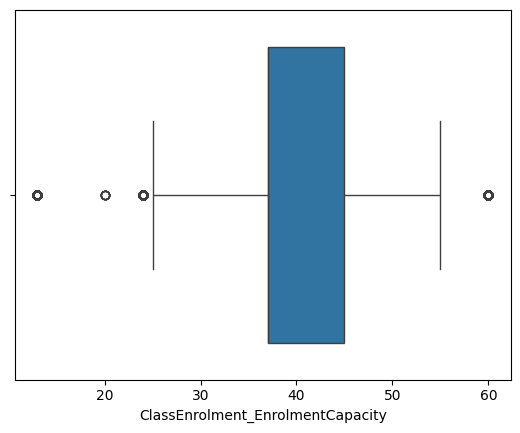

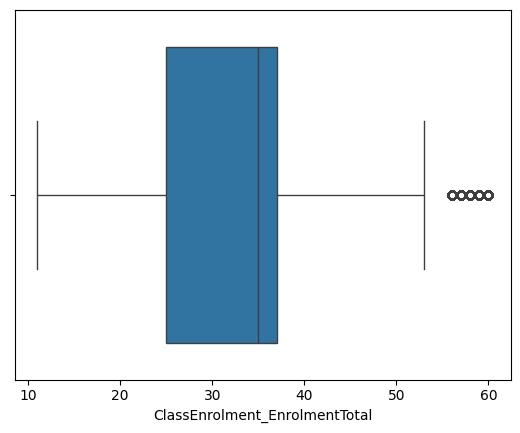

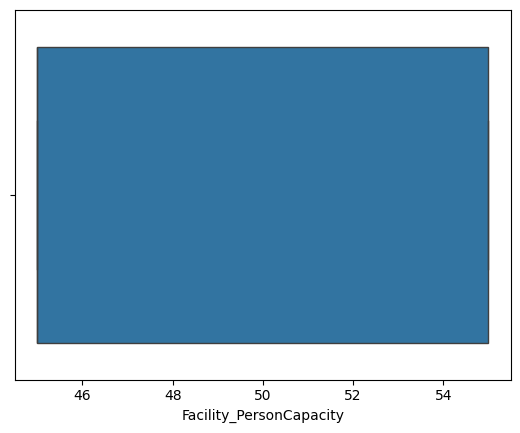

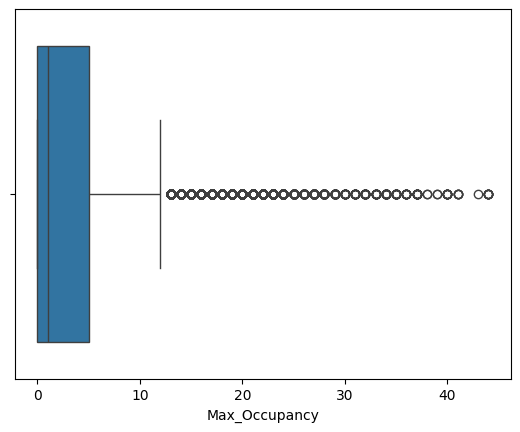

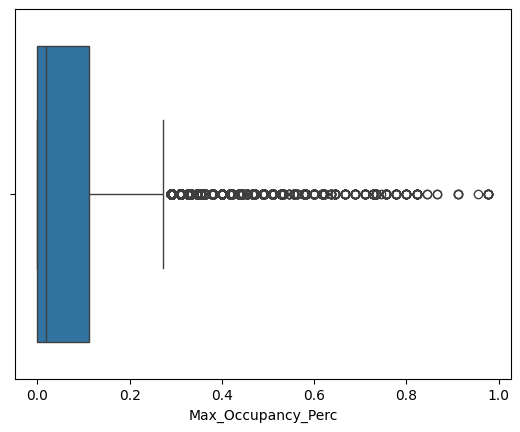

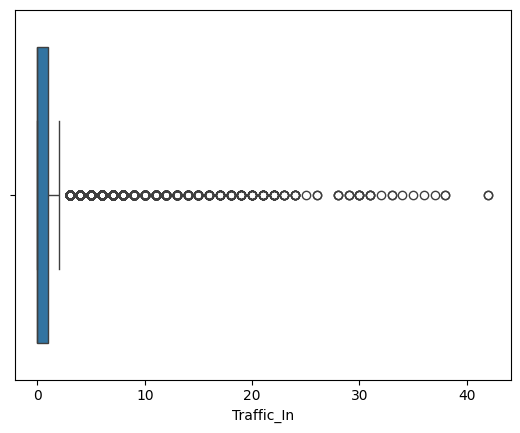

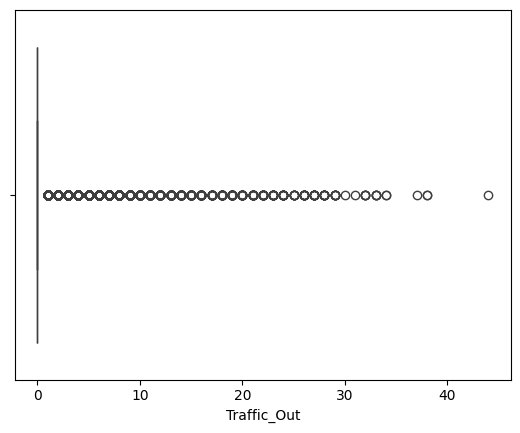

In [ ]:
for col in df.select_dtypes(include=['int64', 'float64']):
  sns.boxplot(x=df[col])
  plt.show()

In [ ]:
df.head()

,Record_Date,Record_Time,Class_ClassSection,ClassEnrolment_EnrolmentCapacity,ClassEnrolment_EnrolmentTotal,Class_InstructionMode,CourseOffer_Subject,Class_Start_Time,Class_End_Time,Facility_ID,Facility_PersonCapacity,Day_of_Week,Max_Occupancy,Max_Occupancy_Perc,Traffic_In,Traffic_Out
0,2021-09-28,1900-01-01 10:30:00,H01,60,37,Hyflex,BUSN,1900-01-01 08:00:00,1900-01-01 09:30:00,3-172,45,Tuesday,4,0.088889,0,7
1,2021-09-28,1900-01-01 10:45:00,H01,60,53,Hyflex,BUSD,1900-01-01 08:00:00,1900-01-01 09:30:00,3-157,55,Tuesday,4,0.072727,4,1
2,2021-09-28,1900-01-01 10:45:00,H01,45,44,Hyflex,BUSD,1900-01-01 08:00:00,1900-01-01 09:30:00,3-154,45,Tuesday,0,0.000000,0,0
3,2021-09-28,1900-01-01 10:45:00,H04,60,58,Hyflex,BUSD,1900-01-01 09:30:00,1900-01-01 11:00:00,3-172,45,Tuesday,0,0.000000,0,0
4,2021-09-28,1900-01-01 10:45:00,H01,60,37,Hyflex,BUSN,1900-01-01 08:00:00,1900-01-01 09:30:00,3-172,45,Tuesday,0,0.000000,0,0


In [ ]:
df.describe()

,Record_Date,Record_Time,ClassEnrolment_EnrolmentCapacity,ClassEnrolment_EnrolmentTotal,Class_Start_Time,Class_End_Time,Facility_PersonCapacity,Max_Occupancy,Max_Occupancy_Perc,Traffic_In,Traffic_Out
count,29259,29259,29259.000000,29259.000000,29259,29259,29259.000000,29259.000000,29259.000000,29259.000000,29259.000000
mean,2022-02-15 22:36:46.582589696,1900-01-01 12:48:19.477083904,40.408695,33.195154,1900-01-01 11:35:04.829283072,1900-01-01 13:49:48.003691008,49.317304,4.138248,0.083799,0.851499,0.962747
min,2021-09-28 00:00:00,1900-01-01 08:00:00,13.000000,11.000000,1900-01-01 08:00:00,1900-01-01 09:30:00,45.000000,0.000000,0.000000,0.000000,0.000000
25%,2021-11-30 00:00:00,1900-01-01 10:15:00,37.000000,25.000000,1900-01-01 09:00:00,1900-01-01 11:00:00,45.000000,0.000000,0.000000,0.000000,0.000000
50%,2022-02-17 00:00:00,1900-01-01 12:45:00,37.000000,35.000000,1900-01-01 11:00:00,1900-01-01 14:00:00,45.000000,1.000000,0.018182,0.000000,0.000000
75%,2022-04-12 00:00:00,1900-01-01 15:00:00,45.000000,37.000000,1900-01-01 14:00:00,1900-01-01 15:30:00,55.000000,5.000000,0.111111,1.000000,0.000000
max,2022-08-18 00:00:00,1900-01-01 21:00:00,60.000000,60.000000,1900-01-01 19:30:00,1900-01-01 21:00:00,55.000000,44.000000,0.977778,42.000000,44.000000
std,NaN,NaN,10.010448,11.027826,NaN,NaN,4.953258,6.621749,0.134693,2.488718,2.975837


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29259 entries, 0 to 32124
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Record_Date                       29259 non-null  datetime64[ns]
 1   Record_Time                       29259 non-null  datetime64[ns]
 2   Class_ClassSection                29259 non-null  category      
 3   ClassEnrolment_EnrolmentCapacity  29259 non-null  int64         
 4   ClassEnrolment_EnrolmentTotal     29259 non-null  int64         
 5   Class_InstructionMode             29259 non-null  category      
 6   CourseOffer_Subject               29259 non-null  category      
 7   Class_Start_Time                  29259 non-null  datetime64[ns]
 8   Class_End_Time                    29259 non-null  datetime64[ns]
 9   Facility_ID                       29259 non-null  object        
 10  Facility_PersonCapacity           29259 non-null  i

In [ ]:
df['CourseOffer_Subject'].value_counts()

CourseOffer_Subject
BUSD    16116
LINC     3731
ELCC     2419
BUSN     1280
COMM     1160
HLTH      967
HEED      722
SETT      491
MATH      278
PHRM      265
CYCD      217
STAT      214
PSYC      181
EASC      160
SOWK      147
ENGL      115
DISB      112
ANTH       97
JUST       89
THPR       86
TRDC       86
MAT        82
XBUS       68
SOCI       63
COSW       62
XLAN       31
EDAS       13
HUMN        7
Name: count, dtype: int64

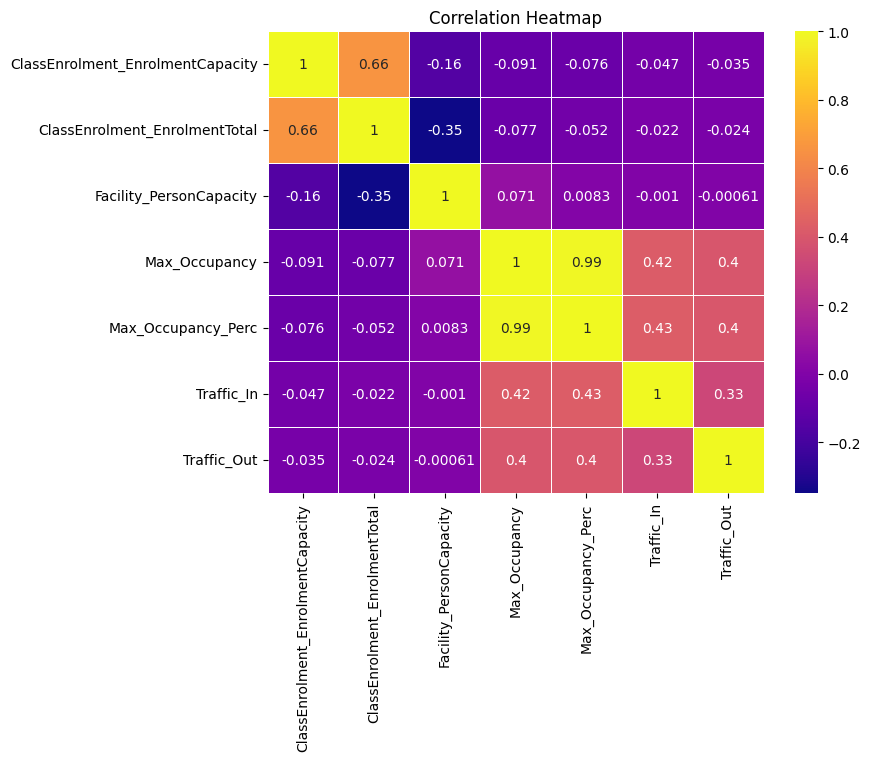

In [ ]:
# creating a heat map
# Filter out non-numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, cmap='plasma', annot=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


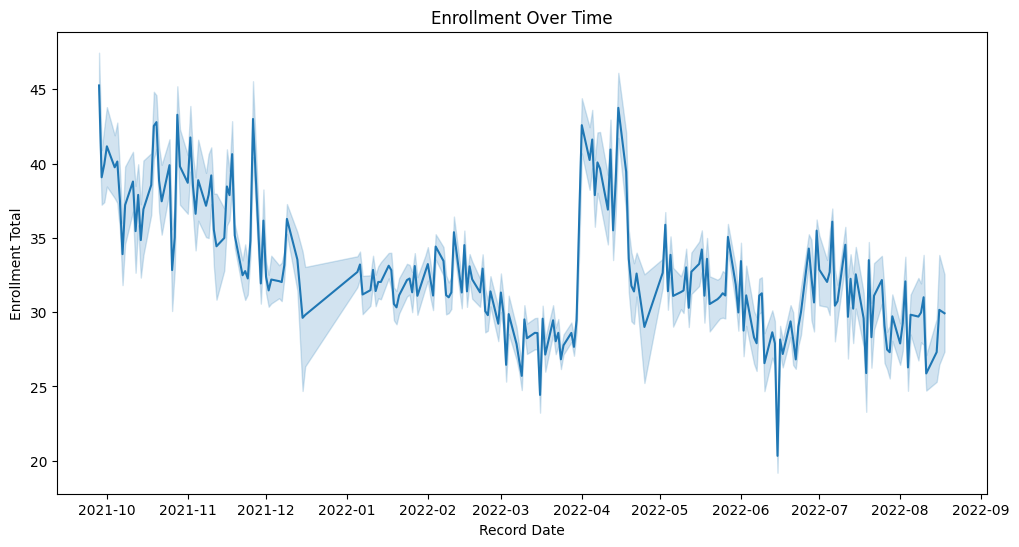

In [ ]:
# Time Series Analysis
plt.figure(figsize=(12, 6))
sns.lineplot(x='Record_Date', y='ClassEnrolment_EnrolmentTotal', data=df)
plt.title('Enrollment Over Time')
plt.xlabel('Record Date')
plt.ylabel('Enrollment Total')
plt.show()

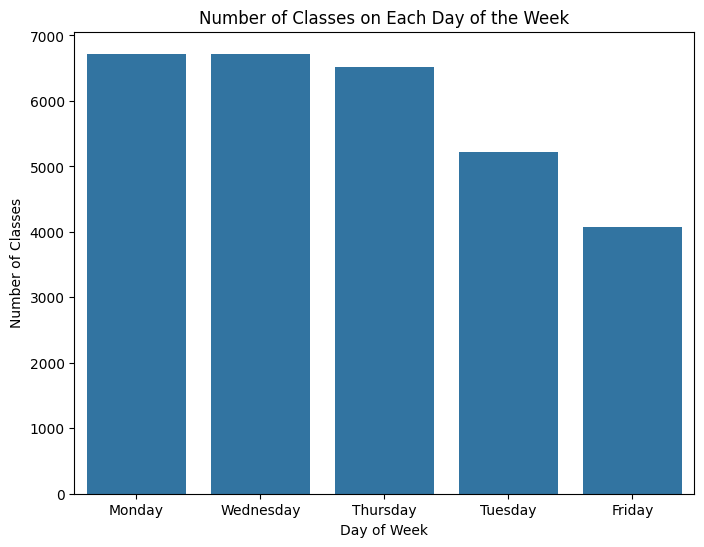

In [ ]:
# Day of Week Analysis
plt.figure(figsize=(8, 6))
sns.countplot(x='Day_of_Week', data=df, order=df['Day_of_Week'].value_counts().index)
plt.title('Number of Classes on Each Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Classes')
plt.show()

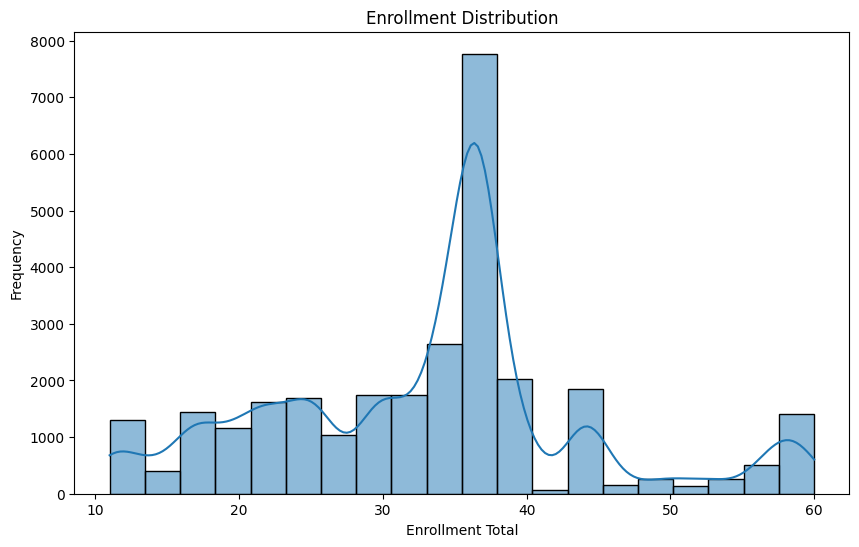

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ClassEnrolment_EnrolmentTotal'], bins=20, kde=True)
plt.title('Enrollment Distribution')
plt.xlabel('Enrollment Total')
plt.ylabel('Frequency')
plt.show()

<ipython-input-29-034c54793422>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Day_of_Week', y='Max_Occupancy', estimator=sum, ci=None)


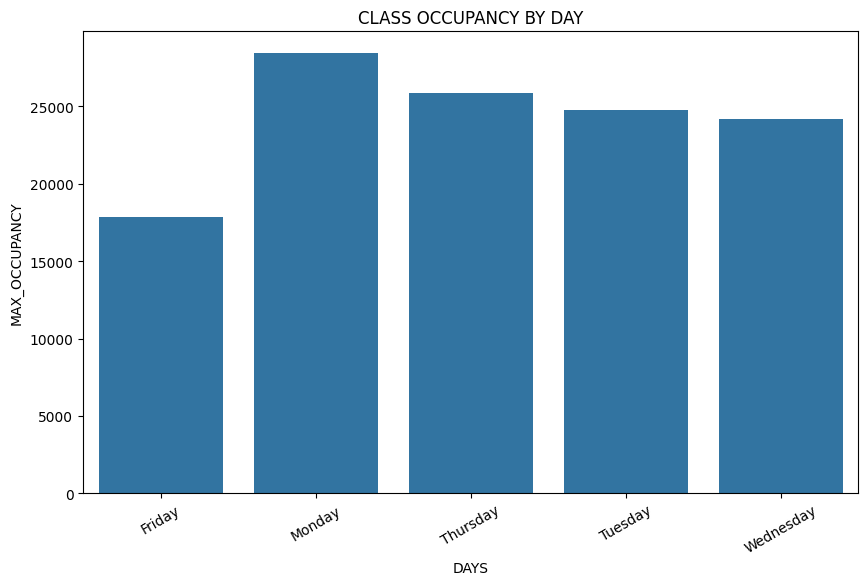

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Day_of_Week', y='Max_Occupancy', estimator=sum, ci=None)
plt.title('CLASS OCCUPANCY BY DAY')
plt.xlabel('DAYS')
plt.ylabel('MAX_OCCUPANCY')
plt.xticks(rotation=30)
plt.show()

<ipython-input-30-c95f274205b7>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Class_InstructionMode', y='Max_Occupancy', estimator=sum, ci=None)


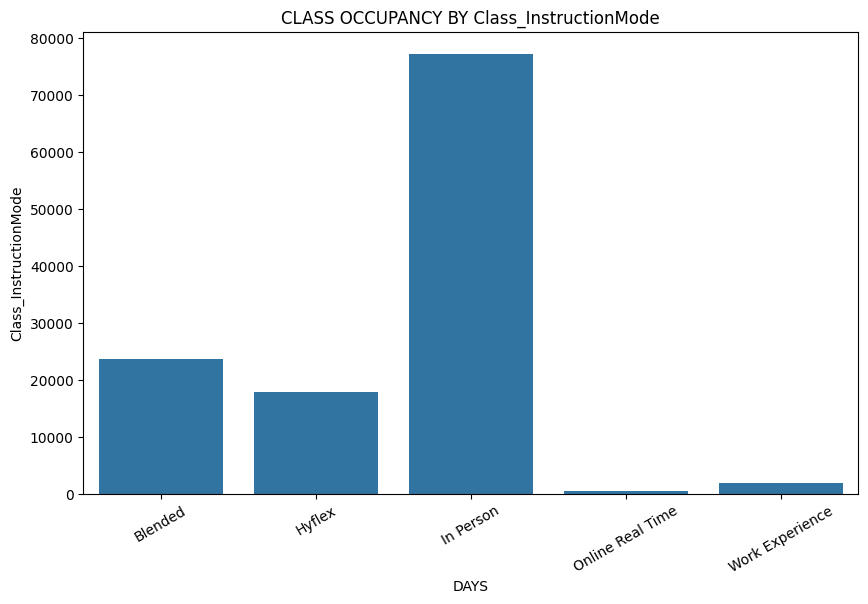

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Class_InstructionMode', y='Max_Occupancy', estimator=sum, ci=None)
plt.title('CLASS OCCUPANCY BY Class_InstructionMode')
plt.xlabel('DAYS')
plt.ylabel('Class_InstructionMode')
plt.xticks(rotation=30)
plt.show()

#AutoML

In [ ]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.1/229.1 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.0/306.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.7/416.7 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.5/120.5 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 37.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 MB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 54.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [ ]:
label='Max_Occupancy'
print("Summary of class variable: \n", df[label].describe())

Summary of class variable: 
 count    29259.000000
mean         4.138248
std          6.621749
min          0.000000
25%          0.000000
50%          1.000000
75%          5.000000
max         44.000000
Name: Max_Occupancy, dtype: float64


In [ ]:
total_data_size = len(df)
train_sample_size = int(0.8 * total_data_size)  # 80% of the data for training
test_sample_size = total_data_size - train_sample_size  # Remaining 20% for testing
print(train_sample_size, test_sample_size)

23407 5852


In [ ]:
train_data = df.sample(n=train_sample_size, random_state=0)
train_data.head()

,Record_Date,Record_Time,Class_ClassSection,ClassEnrolment_EnrolmentCapacity,ClassEnrolment_EnrolmentTotal,Class_InstructionMode,CourseOffer_Subject,Class_Start_Time,Class_End_Time,Facility_ID,Facility_PersonCapacity,Day_of_Week,Max_Occupancy,Max_Occupancy_Perc,Traffic_In,Traffic_Out
2359,2021-10-15,1900-01-01 11:30:00,H01,45,24,Hyflex,BUSD,1900-01-01 11:00:00,1900-01-01 12:30:00,3-166,45,Wednesday,2,0.044444,0,0
30907,2022-07-15,1900-01-01 11:15:00,A01,37,35,In Person,BUSD,1900-01-01 11:00:00,1900-01-01 12:30:00,3-157,55,Tuesday,0,0.000000,0,0
18484,2022-03-03,1900-01-01 09:15:00,A01,37,34,In Person,BUSD,1900-01-01 18:00:00,1900-01-01 21:00:00,3-160,45,Tuesday,9,0.200000,0,0
23814,2022-04-07,1900-01-01 10:30:00,H09,60,60,Hyflex,BUSD,1900-01-01 08:00:00,1900-01-01 09:30:00,3-166,45,Wednesday,3,0.066667,2,3
19564,2022-03-10,1900-01-01 17:30:00,A01,37,37,In Person,BUSD,1900-01-01 12:30:00,1900-01-01 15:30:00,3-160,45,Monday,0,0.000000,0,0


In [ ]:


# Initialize TabularPredictor with presets
predictor = TabularPredictor(label=label)


No path specified. Models will be saved in: "AutogluonModels/ag-20240415_150518"


In [ ]:
predictor.fit(train_data=train_data)

No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets.
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='best_quality'   : Maximize accuracy. Default time_limit=3600.
	presets='high_quality'   : Strong accuracy with fast inference speed. Default time_limit=3600.
	presets='good_quality'   : Good accuracy with very fast inference speed. Default time_limit=3600.
	presets='medium_quality' : Fast training time, ideal for initial prototyping.
Beginning AutoGluon training ...
AutoGluon will save models to "AutogluonModels/ag-20240415_150518"
=================== System Info ===================
AutoGluon Version:  1.0.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sat Nov 18 15:31:17 UTC 2023
CPU Count:          2
Memory Avail:       11.67 GB / 12.67 GB (92.1%)
Disk Space A

In [ ]:
print(train_data.dtypes)

In [ ]:
print(train_data["Record_Date"].describe())

In [ ]:
print(train_data.isnull().sum())

In [ ]:
test_data = df.sample(n=test_sample_size, random_state=0)
test_data.head()

In [ ]:
y_test = test_data[label]  # values to predict
test_data_nolabel = test_data.drop(columns=[label])  # delete label column to prove we're not cheating
test_data_nolabel.head()

In [ ]:

y_pred = predictor.predict(test_data_nolabel)
print("Predictions:  \n", y_pred)
perf = predictor.evaluate_predictions(y_true=y_test, y_pred=y_pred, auxiliary_metrics=True)

In [ ]:
df.head()

#Feature Engineering

One-hot encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [ ]:

df=pd.get_dummies(df, columns=['Class_InstructionMode'],dtype=int)

In [ ]:
df['Day_of_Week'] = label_encoder.fit_transform(df['Day_of_Week'])

In [ ]:
underutilized_threshold = 50  # Example threshold for under-utilized
overutilized_threshold = 80   # Example threshold for over-utilized

In [ ]:
df["ClassEnrolment_EnrolmentAvailable"]=df["ClassEnrolment_EnrolmentCapacity"]-df["ClassEnrolment_EnrolmentTotal"]
df["Utilization_Rate"]=(df["Max_Occupancy_Perc"]*100).astype(float)
df['Utilization_Category'] = pd.cut(df['Utilization_Rate'],
                                    bins=[-float("inf"), underutilized_threshold, overutilized_threshold, float("inf")],
                                    labels=['Under Utilized', 'Optimally Utilized', 'Over Utilized'])

# If you want to represent these categories numerically as well, you can assign them integer codes
category_codes = {'Under Utilized': 0, 'Optimally Utilized': 1, 'Over Utilized': 2}
df['Utilization_Category_Code'] = df['Utilization_Category'].map(category_codes)

In [ ]:
df = df.replace([np.inf, -np.inf], 0)

In [ ]:
df.head()

In [ ]:
category_counts = df['Utilization_Category'].value_counts()
print(category_counts)

In [ ]:
# Plotting the bar plot
plt.figure(figsize=(6, 4))
category_counts.plot(kind='bar', color=['red', 'green','blue'])
plt.title('Utilization Class Distribution')
plt.xlabel('Utilization_Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Select features and target variable
X = df.drop(columns=['Utilization_Category','Utilization_Category_Code'])
y = df['Utilization_Category_Code']
X['Class_ClassSection'] = label_encoder.fit_transform(X['Class_ClassSection'])
X['CourseOffer_Subject'] = label_encoder.fit_transform(X['CourseOffer_Subject'])
X['Facility_ID'] = label_encoder.fit_transform(X['Facility_ID'])
X['Record_Date'] = X['Record_Date'].astype(int) // 10**9
X['Record_Time'] = X['Record_Time'].astype(int) // 10**9
X['Class_Start_Time'] = X['Class_Start_Time'].astype(int) // 10**9
X['Class_End_Time'] = X['Class_End_Time'].astype(int) // 10**9
# Print the shapes of X and y
print(X.shape)
print(y.shape)


In [ ]:
X.head()

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Implement K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Implement Decision Trees
decision_tree = DecisionTreeClassifier(max_depth=1)
decision_tree.fit(X_train, y_train)
y_pred_decision_tree = decision_tree.predict(X_test)

# Implement Random Forest
random_forest = RandomForestClassifier(n_estimators=20)
random_forest.fit(X_train, y_train)
y_pred_random_forest = random_forest.predict(X_test)

In [ ]:
print("K-Nearest Neighbors (KNN) Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_decision_tree))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_random_forest))

In [ ]:
# prompt: use cross valiadtaion to optimize the above models

# Implementing cross-validation for KNN
from sklearn.model_selection import cross_val_score
knn = KNeighborsClassifier(n_neighbors=10)
scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
print("KNN Cross-Validation Accuracy Scores:", scores)
print("Average KNN Cross-Validation Accuracy:", scores.mean())

# Implementing cross-validation for Decision Tree
decision_tree = DecisionTreeClassifier(max_depth=1)
scores = cross_val_score(decision_tree, X, y, cv=5, scoring='accuracy')
print("Decision Tree Cross-Validation Accuracy Scores:", scores)
print("Average Decision Tree Cross-Validation Accuracy:", scores.mean())

# Implementing cross-validation for Random Forest
random_forest = RandomForestClassifier(n_estimators=50)
scores = cross_val_score(random_forest, X, y, cv=5, scoring='accuracy')
print("Random Forest Cross-Validation Accuracy Scores:", scores)
print("Average Random Forest Cross-Validation Accuracy:", scores.mean())


#Solution 2:

In [ ]:
# prompt: I want to make a time series forecasting for Allocation which predicts the future attendance pattern for each class to optimize room assignments and scheduling

# Import necessary libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Define the time series cross-validation object
tscv = TimeSeriesSplit(n_splits=5)

# Initialize lists to store the performance metrics
mse_list = []
mae_list = []
r2_list = []

# Loop through the time series cross-validation folds
for train_index, test_index in tscv.split(X):
    # Split the data into training and testing sets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train the Random Forest model
    random_forest = RandomForestRegressor(n_estimators=100)
    random_forest.fit(X_train, y_train)

    # Predict the future attendance
    y_pred = random_forest.predict(X_test)

    # Evaluate the model performance
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append the performance metrics to the lists
    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)

# Print the average performance metrics
print("Average MSE:", sum(mse_list) / len(mse_list))
print("Average MAE:", sum(mae_list) / len(mae_list))
print("Average R2:", sum(r2_list) / len(r2_list))


#Regression Model

In [ ]:
# Select features and target variable
X1 = df.drop(columns=['Utilization_Category','Utilization_Category_Code','Max_Occupancy','Max_Occupancy_Perc'])
y1 = df['Max_Occupancy']
X1['Class_ClassSection'] = label_encoder.fit_transform(X1['Class_ClassSection'])
X1['CourseOffer_Subject'] = label_encoder.fit_transform(X1['CourseOffer_Subject'])
X1['Facility_ID'] = label_encoder.fit_transform(X1['Facility_ID'])
X1['Record_Date'] = X1['Record_Date'].astype(int) // 10**9
X1['Record_Time'] = X1['Record_Time'].astype(int) // 10**9
X1['Class_Start_Time'] = X1['Class_Start_Time'].astype(int) // 10**9
X1['Class_End_Time'] = X1['Class_End_Time'].astype(int) // 10**9
# Print the shapes of X and y
print(X1.shape)
print(y1.shape)

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)



# Train three regression models
models = [
    DecisionTreeRegressor(),
    KNeighborsRegressor(),
    RandomForestRegressor(),
    GradientBoostingRegressor()
]

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model performance
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Print the model name and performance metrics
    print(f"Model: {model.__class__.__name__}")
    print(f"MSE: {mse:.2f}")
    print(f"R2: {r2:.2f}")
    print()


In [ ]:
# prompt: optimize the above regression models using cross validation

# Import necessary libraries
from sklearn.model_selection import GridSearchCV

# Define the grid of hyperparameters to search for each model
param_grids = {
    DecisionTreeRegressor(): {
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10],
    },
    KNeighborsRegressor(): {
        'n_neighbors': [5, 10, 15],
        'weights': ['uniform', 'distance'],
    },
    RandomForestRegressor(): {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
    },
    GradientBoostingRegressor(): {
        'learning_rate': [0.1, 0.5, 1],
        'n_estimators': [50, 100, 200],
    }
}

# Perform grid search cross-validation for each model
for model, param_grid in param_grids.items():
    grid_search = GridSearchCV(model, param_grid, cv=5)
    grid_search.fit(X_train, y_train)

    # Print the best parameters and score for each model
    print(f"Model: {model.__class__.__name__}")
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best score: {grid_search.best_score_}")
    print()



In [ ]:
automl = autosklearn.classification.AutoSklearnClassifier(time_left_for_this_task=120, per_run_time_limit=30)

# Fit AutoML model
automl.fit(X_train, y_train)

# Get predictions
y_pred = automl.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


In [ ]:
!python -m pip install --upgrade pip
!python -m pip install autogluon